# Notebook Purpose

This Jupyter notebook retrieves the financial data of different assets in the same folder, then calculates the correlation between these assets, ranging from -1 for negatively correlated assets to 1 for positively correlated ones. Finally, it lists the 5 most positively correlated assets.

In [1]:
%pip install pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
DATA_DIR = "../../data/sp500_top30"

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# Scan all CSV files in the folder
csv_files = glob.glob(f"{DATA_DIR}/*.csv")
print(f"CSVs trouvés ({len(csv_files)}):")
for f in csv_files:
    print(f"  - {Path(f).name}")

# Dictionary for storing data
prices = {}
for file in csv_files:
    ticker = Path(file).stem.split('_')[0]
    df = pd.read_csv(file, parse_dates=['Date']).set_index('Date')
    prices[ticker] = df['Adj Close']

# Combined DataFrame (common dates)
df_combined = pd.DataFrame(prices).dropna()
print(f"\nPériode commune ({len(df_combined.columns)} stocks):")
print(f"  {df_combined.index.min()} → {df_combined.index.max()}")
print(f"  {len(df_combined)} jours")

CSVs trouvés (30):
  - NFLX_1d_2017-01-01_2026-03-01.csv
  - PG_1d_2017-01-01_2026-03-01.csv
  - AAPL_1d_2017-01-01_2026-03-01.csv
  - ACN_1d_2017-01-01_2026-03-01.csv
  - JPM_1d_2017-01-01_2026-03-01.csv
  - MA_1d_2017-01-01_2026-03-01.csv
  - JNJ_1d_2017-01-01_2026-03-01.csv
  - TSLA_1d_2017-01-01_2026-03-01.csv
  - V_1d_2017-01-01_2026-03-01.csv
  - BLK_1d_2017-01-01_2026-03-01.csv
  - BAC_1d_2017-01-01_2026-03-01.csv
  - NVDA_1d_2017-01-01_2026-03-01.csv
  - CRM_1d_2017-01-01_2026-03-01.csv
  - ORCL_1d_2017-01-01_2026-03-01.csv
  - AMD_1d_2017-01-01_2026-03-01.csv
  - LLY_1d_2017-01-01_2026-03-01.csv
  - AMZN_1d_2017-01-01_2026-03-01.csv
  - XOM_1d_2017-01-01_2026-03-01.csv
  - ADBE_1d_2017-01-01_2026-03-01.csv
  - GOOG_1d_2017-01-01_2026-03-01.csv
  - UNH_1d_2017-01-01_2026-03-01.csv
  - META_1d_2017-01-01_2026-03-01.csv
  - BRK-B_1d_2017-01-01_2026-03-01.csv
  - HD_1d_2017-01-01_2026-03-01.csv
  - AVGO_1d_2017-01-01_2026-03-01.csv
  - MSFT_1d_2017-01-01_2026-03-01.csv
  - WMT_1d_

In [4]:
returns = df_combined.pct_change().dropna()
corr_matrix = returns.corr()

print("Correlations (daily returns):")
print(corr_matrix.round(4))
print(f"\nMax correlation: {corr_matrix.values.max():.4f}")
print(f"Min correlation: {corr_matrix.values.min():.4f}")

Correlations (daily returns):
         NFLX      PG    AAPL     ACN     JPM      MA     JNJ    TSLA       V  \
NFLX   1.0000  0.1452  0.4348  0.3667  0.2277  0.3659  0.1293  0.3380  0.3656   
PG     0.1452  1.0000  0.3424  0.3937  0.2941  0.3837  0.5220  0.0958  0.3943   
AAPL   0.4348  0.3424  1.0000  0.5288  0.4207  0.5812  0.3029  0.4471  0.5714   
ACN    0.3667  0.3937  0.5288  1.0000  0.5022  0.6222  0.3655  0.3109  0.6213   
JPM    0.2277  0.2941  0.4207  0.5022  1.0000  0.5748  0.3380  0.2829  0.5834   
MA     0.3659  0.3837  0.5812  0.6222  0.5748  1.0000  0.3728  0.3333  0.9023   
JNJ    0.1293  0.5220  0.3029  0.3655  0.3380  0.3728  1.0000  0.0717  0.3903   
TSLA   0.3380  0.0958  0.4471  0.3109  0.2829  0.3333  0.0717  1.0000  0.3420   
V      0.3656  0.3943  0.5714  0.6213  0.5834  0.9023  0.3903  0.3420  1.0000   
BLK    0.3573  0.3758  0.5551  0.6100  0.6628  0.6259  0.3923  0.3606  0.6202   
BAC    0.2275  0.2906  0.4266  0.4900  0.8841  0.5517  0.3182  0.2836  0.5614  

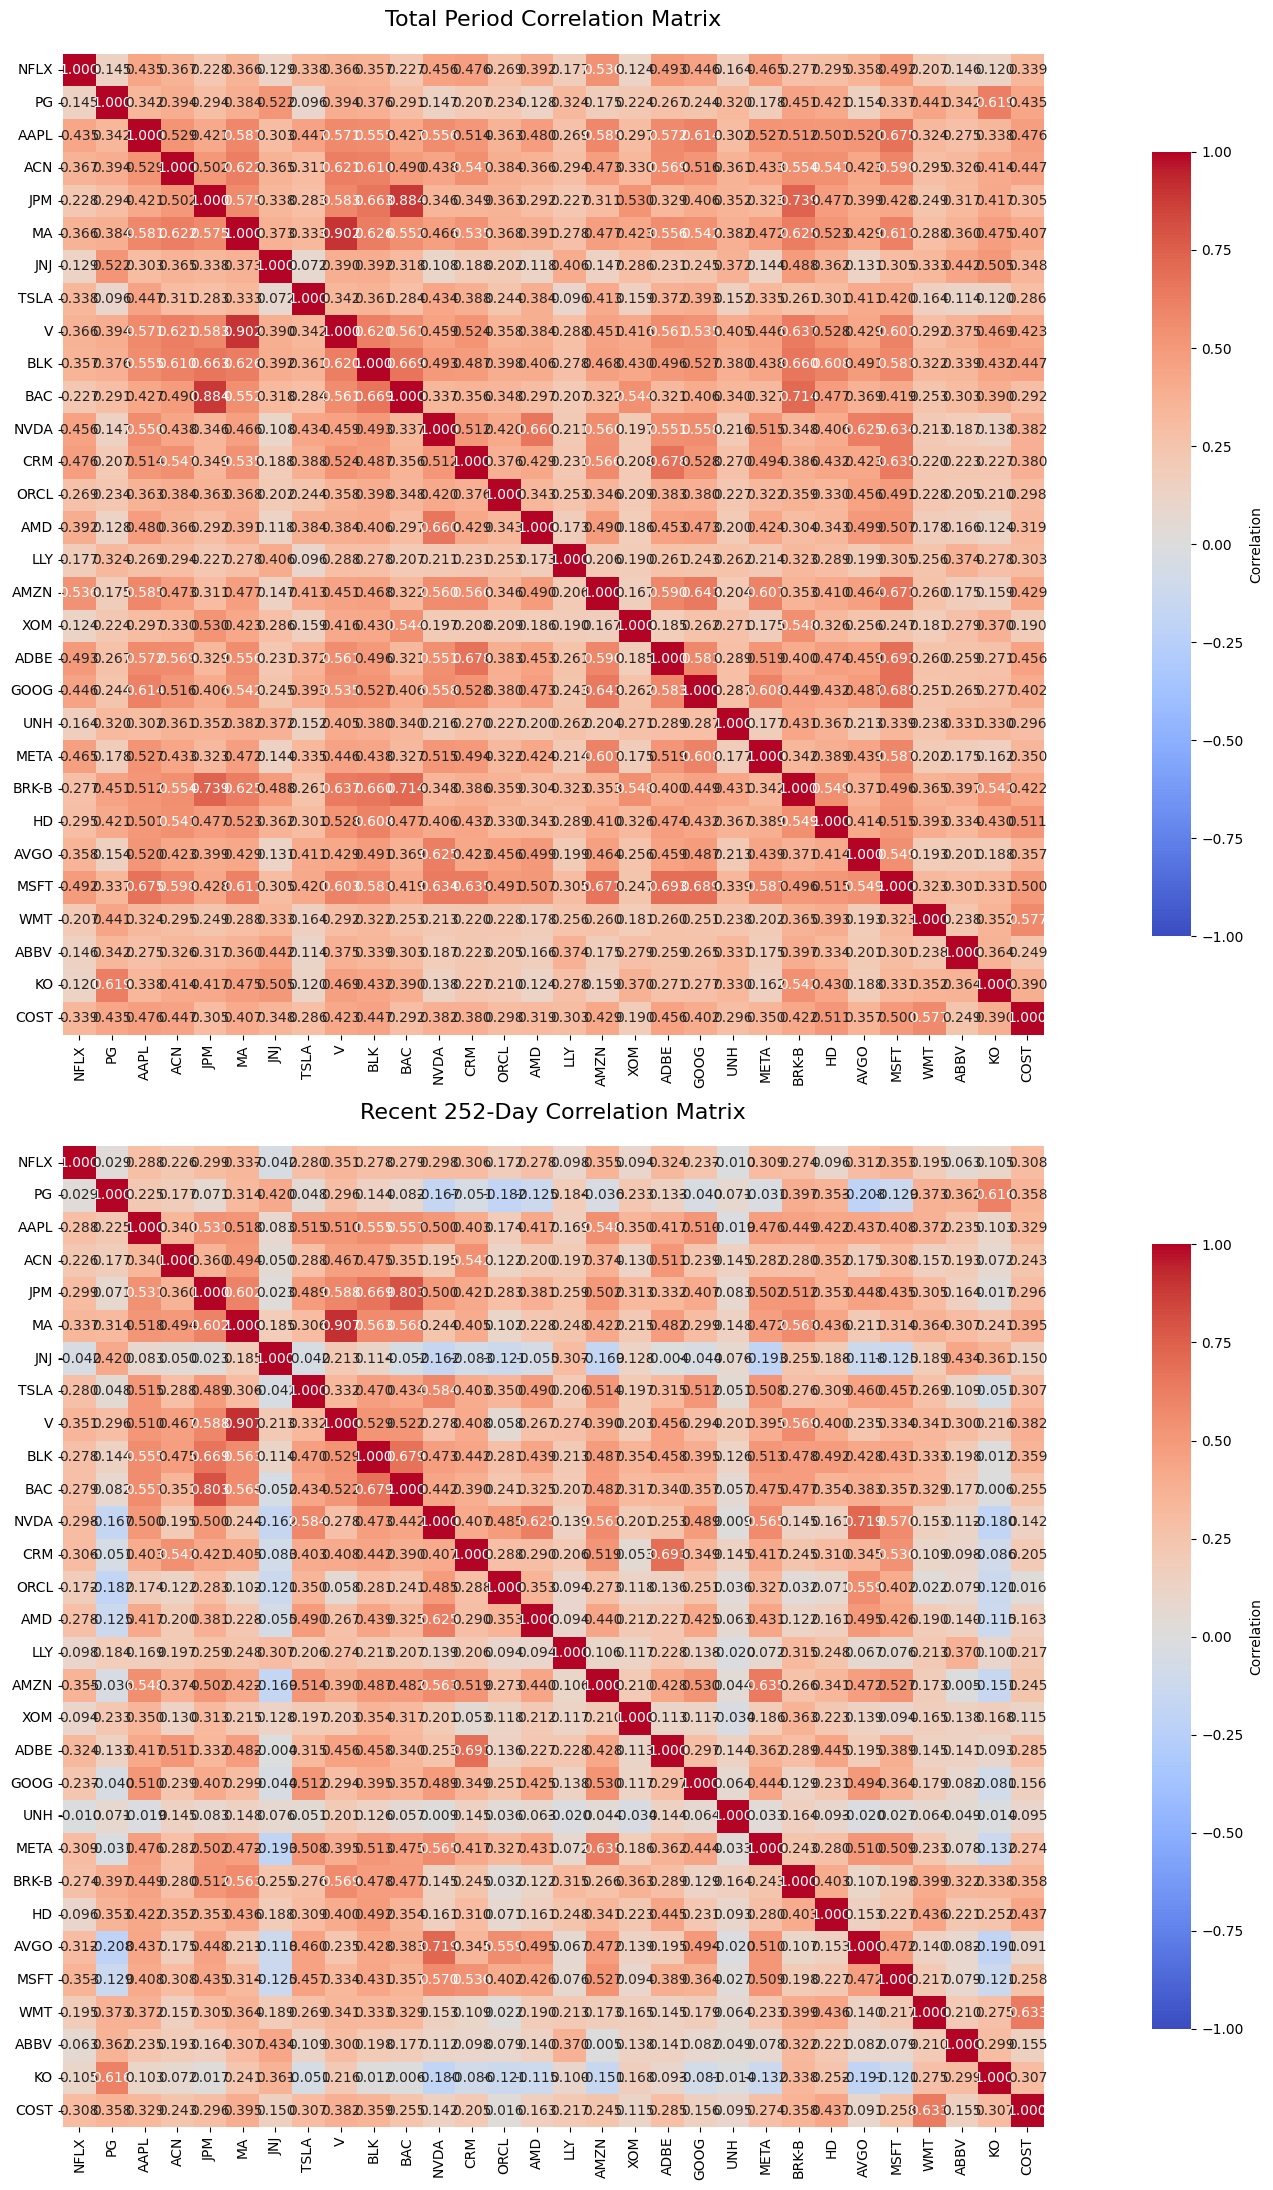

In [5]:
import numpy as np
import pandas as pd

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 22))

# 1. Total Correlation Matrix (BLUE → RED, -1 to +1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, vmin=-1, vmax=1,
            fmt='.3f', cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax1)
ax1.set_title('Total Period Correlation Matrix', fontsize=16, pad=20)

# 2. 252-day Correlation Matrix (-1 to +1)
returns = df_combined.pct_change().dropna()
rolling_period = 252
recent_returns = returns.tail(rolling_period)
rolling_corr_matrix = recent_returns.corr()

sns.heatmap(rolling_corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, vmin=-1, vmax=1,
            fmt='.3f', cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax2)
ax2.set_title('Recent 252-Day Correlation Matrix', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

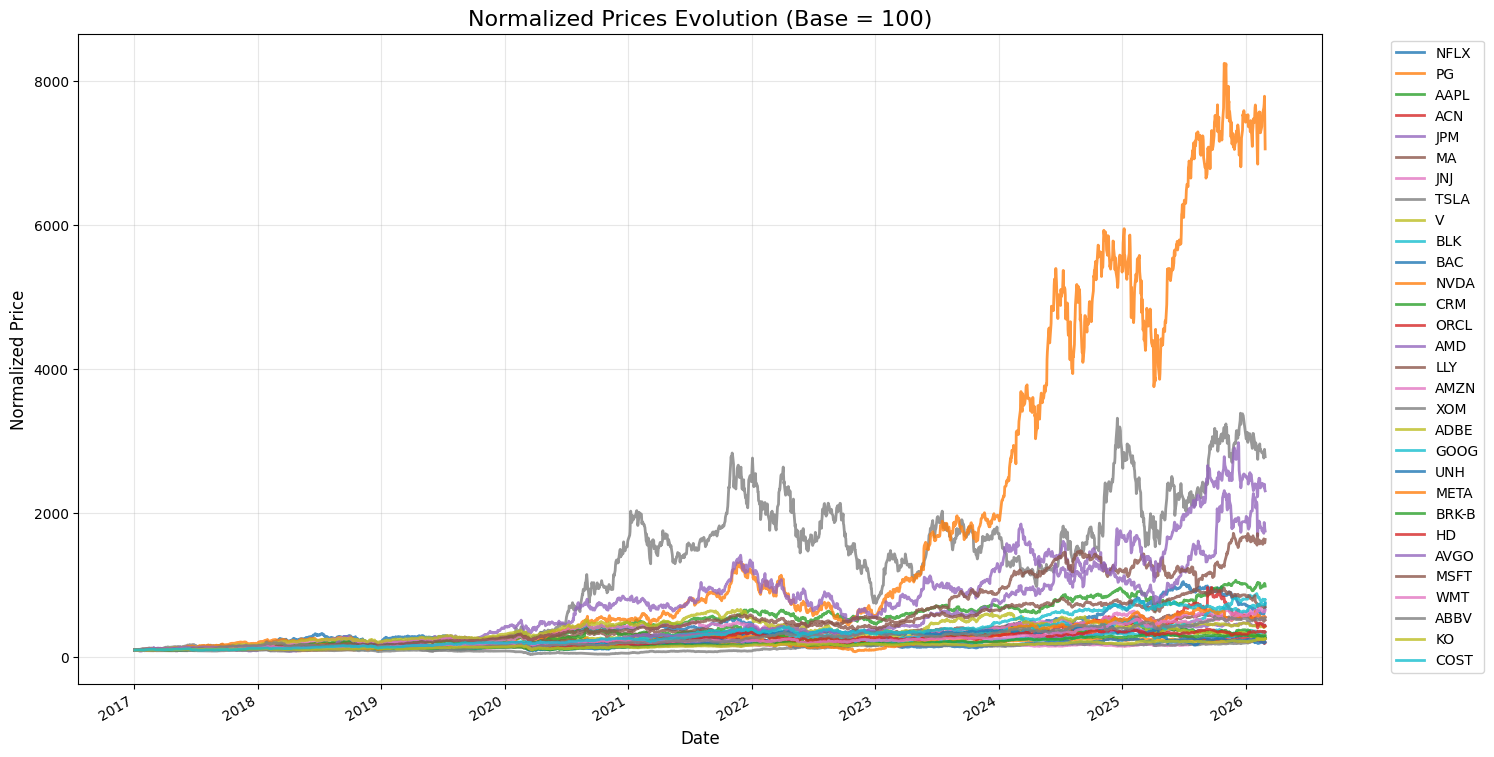

In [6]:
# Cellule VISU — Price Evolution (Normalized)
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Normalize prices to 100 at start (common comparison)
normalized_prices = (df_combined / df_combined.iloc[0]) * 100
normalized_prices.plot(ax=ax, linewidth=2, alpha=0.8)

ax.set_title('Normalized Prices Evolution (Base = 100)', fontsize=16)
ax.set_ylabel('Normalized Price', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Cellule TOP CORR — Top 5 Positive Correlations (SIMPLE)
import pandas as pd
import numpy as np

# Extract all unique pairs from upper triangle
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        asset1 = corr_matrix.columns[i]
        asset2 = corr_matrix.columns[j]
        corr = corr_matrix.loc[asset1, asset2]
        corr_pairs.append([asset1, asset2, corr])

# Convert to DataFrame and sort
corr_df = pd.DataFrame(corr_pairs, columns=['Asset1', 'Asset2', 'Correlation'])
top_corr = corr_df.nlargest(5, 'Correlation')

print("TOP 5 POSITIVE CORRELATIONS")
print("="*50)
if len(top_corr) > 0:
    for _, row in top_corr.iterrows():
        print(f"{row['Asset1']:>10} ↔ {row['Asset2']:>10} : {row['Correlation']:.4f}")
else:
    print("No positive correlations found")

TOP 5 POSITIVE CORRELATIONS
        MA ↔          V : 0.9023
       JPM ↔        BAC : 0.8841
       JPM ↔      BRK-B : 0.7389
       BAC ↔      BRK-B : 0.7139
      ADBE ↔       MSFT : 0.6928
